In [36]:
# 1.	Import the CSV using pandas and display the first 10 rows.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("movies.csv")

print(df.head(10))

                                MOVIES         YEAR  \
0                        Blood Red Sky       (2021)   
1  Masters of the Universe: Revelation     (2021– )   
2                     The Walking Dead  (2010–2022)   
3                       Rick and Morty     (2013– )   
4                      Army of Thieves       (2021)   
5                          Outer Banks     (2020– )   
6      The Last Letter from Your Lover       (2021)   
7                               Dexter  (2006–2013)   
8                    Never Have I Ever     (2020– )   
9                         Virgin River     (2019– )   

                                        GENRE  RATING  \
0      \nAction, Horror, Thriller                 6.1   
1  \nAnimation, Action, Adventure                 5.0   
2       \nDrama, Horror, Thriller                 8.2   
3  \nAnimation, Adventure, Comedy                 9.2   
4         \nAction, Crime, Horror                 NaN   
5          \nAction, Crime, Drama                 7.

In [37]:
# 2.	Report the number of rows, columns and each column's data type.
df.head(10)

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN
5,Outer Banks,(2020– ),"\nAction, Crime, Drama",7.6,\nA group of teenagers from the wrong side of ...,"\n \n Stars:\nChase Stokes, \nMa...","25,858",50.0,NaN
6,The Last Letter from Your Lover,(2021),"\nDrama, Romance",6.8,\nA pair of interwoven stories set in the past...,\n Director:\nAugustine Frizzell\n| \n S...,"5,283",110.0,NaN
7,Dexter,(2006–2013),"\nCrime, Drama, Mystery",8.6,"\nBy day, mild-mannered Dexter is a blood-spat...","\n \n Stars:\nMichael C. Hall, \...","665,387",53.0,NaN
8,Never Have I Ever,(2020– ),\nComedy,7.9,\nThe complicated life of a modern-day first g...,\n \n Stars:\nMaitreyi Ramakrish...,"34,530",30.0,NaN
9,Virgin River,(2019– ),"\nDrama, Romance",7.4,"\nSeeking a fresh start, nurse practitioner Me...",\n \n Stars:\nAlexandra Breckenr...,"27,279",44.0,NaN


In [38]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])


Number of Rows: 9999
Number of Columns: 9


In [39]:
print("\nColumn Data Types:")
print(df.dtypes)


Column Data Types:
MOVIES          str
YEAR            str
GENRE           str
RATING      float64
ONE-LINE        str
STARS           str
VOTES           str
RunTime     float64
Gross           str
dtype: object


In [40]:
# 3.	Create a data-quality summary showing missing values for every column.
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
MOVIES         0
YEAR         644
GENRE         80
RATING      1820
ONE-LINE       0
STARS          0
VOTES       1820
RunTime     2958
Gross       9539
dtype: int64


In [41]:
# Missing percentage
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

print(missing_summary)

          Missing Values  Missing Percentage
MOVIES                 0            0.000000
YEAR                 644            6.440644
GENRE                 80            0.800080
RATING              1820           18.201820
ONE-LINE               0            0.000000
STARS                  0            0.000000
VOTES               1820           18.201820
RunTime             2958           29.582958
Gross               9539           95.399540


In [42]:
# 4.	Check for duplicate records and decide how duplicates should be handled.
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 431


In [43]:
duplicates = df[df.duplicated()]

print(duplicates)

                    MOVIES      YEAR  \
6833   Mighty Little Bheem  (2019– )   
6835   Mighty Little Bheem  (2019– )   
6836   Mighty Little Bheem  (2019– )   
6837   Mighty Little Bheem  (2019– )   
6838   Mighty Little Bheem  (2019– )   
...                    ...       ...   
9989                  1899  (2022– )   
9990                  1899  (2022– )   
9991                  1899  (2022– )   
9992                  1899  (2022– )   
9994        The Imperfects  (2021– )   

                                          GENRE  RATING        ONE-LINE  \
6833  \nAnimation, Short, Adventure                 NaN  \nAdd a Plot\n   
6835  \nAnimation, Short, Adventure                 9.0  \nAdd a Plot\n   
6836  \nAnimation, Short, Adventure                 9.0  \nAdd a Plot\n   
6837  \nAnimation, Short, Adventure                 NaN  \nAdd a Plot\n   
6838  \nAnimation, Short, Adventure                 NaN  \nAdd a Plot\n   
...                                         ...     ...             .

In [44]:
# drop duplicates
df = df.drop_duplicates()

In [45]:
# check new size
print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 9568


In [46]:
# 5.	Convert suitable columns to numeric or date formats where possible.
df["VOTES"] = (
    df["VOTES"]
    .str.replace(",", "", regex=False)
)

df["VOTES"] = pd.to_numeric(
    df["VOTES"],
    errors="coerce"
)

In [47]:
df["Release_Year"] = (
    df["YEAR"]
    .astype(str)
    .str.extract(r"(\d{4})")[0]
)

df["Release_Year"] = pd.to_numeric(
    df["Release_Year"],
    errors="coerce"
)

In [48]:
print(df[["YEAR", "Release_Year"]].head(20))

           YEAR  Release_Year
0        (2021)        2021.0
1      (2021– )        2021.0
2   (2010–2022)        2010.0
3      (2013– )        2013.0
4        (2021)        2021.0
5      (2020– )        2020.0
6        (2021)        2021.0
7   (2006–2013)        2006.0
8      (2020– )        2020.0
9      (2019– )        2019.0
10       (2021)        2021.0
11  (2016–2021)        2016.0
12       (2021)        2021.0
13     (2021– )        2021.0
14     (2011– )        2011.0
15     (2005– )        2005.0
16  (2008–2013)        2008.0
17     (2017– )        2017.0
18  (2017–2021)        2017.0
19     (2016– )        2016.0


In [49]:
print(df.dtypes)

MOVIES              str
YEAR                str
GENRE               str
RATING          float64
ONE-LINE            str
STARS               str
VOTES           float64
RunTime         float64
Gross               str
Release_Year    float64
dtype: object


In [50]:
genre_df = df.dropna(subset=["GENRE"]).copy()
print((genre_df[["GENRE"]].head(20)))

                                         GENRE
0       \nAction, Horror, Thriller            
1   \nAnimation, Action, Adventure            
2        \nDrama, Horror, Thriller            
3   \nAnimation, Adventure, Comedy            
4          \nAction, Crime, Horror            
5           \nAction, Crime, Drama            
6                 \nDrama, Romance            
7          \nCrime, Drama, Mystery            
8                         \nComedy            
9                 \nDrama, Romance            
10   \nAction, Adventure, Thriller            
11         \nCrime, Drama, Fantasy            
12        \nDrama, Horror, Mystery            
13        \nComedy, Drama, Romance            
14       \nDrama, Horror, Thriller            
15                \nDrama, Romance            
16        \nCrime, Drama, Thriller            
17                         \nDrama            
18                 \nComedy, Drama            
19        \nDrama, Fantasy, Horror            


In [51]:
genre_df = df.dropna(subset=["GENRE"]).copy()

genre_df["GENRE"] = genre_df["GENRE"].str.split(",")

genre_df = genre_df.explode("GENRE")

genre_df["GENRE"] = genre_df["GENRE"].str.strip()

print(genre_df[["MOVIES", "GENRE"]].head(20))

                                MOVIES      GENRE
0                        Blood Red Sky     Action
0                        Blood Red Sky     Horror
0                        Blood Red Sky   Thriller
1  Masters of the Universe: Revelation  Animation
1  Masters of the Universe: Revelation     Action
1  Masters of the Universe: Revelation  Adventure
2                     The Walking Dead      Drama
2                     The Walking Dead     Horror
2                     The Walking Dead   Thriller
3                       Rick and Morty  Animation
3                       Rick and Morty  Adventure
3                       Rick and Morty     Comedy
4                      Army of Thieves     Action
4                      Army of Thieves      Crime
4                      Army of Thieves     Horror
5                          Outer Banks     Action
5                          Outer Banks      Crime
5                          Outer Banks      Drama
6      The Last Letter from Your Lover      Drama


In [52]:
print(df["Gross"].head(20))

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5     NaN
6     NaN
7     NaN
8     NaN
9     NaN
10    NaN
11    NaN
12    NaN
13    NaN
14    NaN
15    NaN
16    NaN
17    NaN
18    NaN
19    NaN
Name: Gross, dtype: str


In [53]:
# 7.	Calculate suitable descriptive statistics for numeric columns such as count, mean, median, minimum and maximum.
numeric_columns = [
    "RATING",
    "VOTES",
    "RunTime",
    "Release_Year"
]

print(df[numeric_columns].describe())

            RATING         VOTES      RunTime  Release_Year
count  8168.000000  8.168000e+03  7008.000000   8933.000000
mean      6.919699  1.514441e+04    68.874144   2016.125378
std       1.219970  7.009954e+04    47.278890      7.387275
min       1.100000  5.000000e+00     1.000000   1932.000000
25%       6.200000  1.670000e+02    37.000000   2015.000000
50%       7.100000  7.925000e+02    60.000000   2018.000000
75%       7.800000  3.780750e+03    95.000000   2020.000000
max       9.900000  1.713028e+06   853.000000   2023.000000


In [54]:
# show count, mean, median, min and max
descriptive_stats = pd.DataFrame({
    "Count": df[numeric_columns].count(),
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Minimum": df[numeric_columns].min(),
    "Maximum": df[numeric_columns].max()
})

print(descriptive_stats)

              Count          Mean  Median  Minimum    Maximum
RATING         8168      6.919699     7.1      1.1        9.9
VOTES          8168  15144.414422   792.5      5.0  1713028.0
RunTime        7008     68.874144    60.0      1.0      853.0
Release_Year   8933   2016.125378  2018.0   1932.0     2023.0


In [55]:
# 8.	Identify the highest-rated movies using an appropriate rating field. Clearly state how you handle movies with missing ratings.
# Remove missing ratings for this calculation
rated_movies = df.dropna(subset=["RATING"])

In [56]:
# Sort by rating

top_rated = (
    df.dropna(subset=["RATING"])
      .sort_values("RATING", ascending=False)
      .head(10)
)

print(
    top_rated[
        ["MOVIES", "RATING", "VOTES"]
    ]
)

                                   MOVIES  RATING    VOTES
7640                      BoJack Horseman     9.9  12369.0
8510           Avatar: The Last Airbender     9.9   8813.0
9892                               Dexter     9.8  11638.0
8509           Avatar: The Last Airbender     9.8   5283.0
8767                                 Dark     9.7  20230.0
8541                  The Midnight Gospel     9.7   1731.0
8637   She-Ra and the Princesses of Power     9.7   1434.0
8629   She-Ra and the Princesses of Power     9.7   1262.0
7159           Avatar: The Last Airbender     9.7   2770.0
6626                               Dexter     9.6   8434.0


In [57]:
# 9.	Identify the most popular movies using the dataset's available popularity-related field, if present. 
# take(votes) 
top_popular = (
    df.dropna(subset=["VOTES"])
      .sort_values("VOTES", ascending=False)
      .head(10)
)

print(
    top_popular[
        ["MOVIES", "RATING", "VOTES"]
    ]
)

                                                MOVIES  RATING      VOTES
111  The Lord of the Rings: The Fellowship of the Ring     8.8  1713028.0
193      The Lord of the Rings: The Return of the King     8.9  1691777.0
16                                        Breaking Bad     9.4  1552311.0
260              The Lord of the Rings: The Two Towers     8.7  1529752.0
132                                       The Departed     8.5  1227522.0
156                                  Kill Bill: Vol. 1     8.1  1034554.0
85                                       Jurassic Park     8.1   897444.0
143                                          Gone Girl     8.1   895888.0
19                                     Stranger Things     8.7   885856.0
2                                     The Walking Dead     8.2   885805.0


In [58]:
# 10.	Analyze movie counts by genre or another suitable categorical field. 
   # If genres contain multiple values in one cell, create a beginner-friendly method to split/count them.

# GENRE COUNTS

genre_counts = (
    genre_df["GENRE"]
    .value_counts()
)

print(genre_counts)

GENRE
Drama          4115
Comedy         2736
Action         2110
Adventure      1588
Animation      1584
Crime          1519
Documentary    1221
Thriller        895
Mystery         840
Romance         835
Fantasy         537
Horror          518
Family          442
Reality-TV      370
History         346
Biography       311
Sci-Fi          303
Short           247
Music           200
Sport           192
Game-Show        98
Talk-Show        89
Musical          61
War              48
Western          24
News             23
Film-Noir        12
Name: count, dtype: int64


In [59]:
# top 10 genres
top_genres = genre_counts.head(10)

print(top_genres)

GENRE
Drama          4115
Comedy         2736
Action         2110
Adventure      1588
Animation      1584
Crime          1519
Documentary    1221
Thriller        895
Mystery         840
Romance         835
Name: count, dtype: int64


In [60]:
# Create a DataFrame (This will be useful for charts.)

genre_count_df = (
    genre_counts
    .reset_index()
)

genre_count_df.columns = [
    "Genre",
    "Movie_Count"
]

print(genre_count_df.head(10))

         Genre  Movie_Count
0        Drama         4115
1       Comedy         2736
2       Action         2110
3    Adventure         1588
4    Animation         1584
5        Crime         1519
6  Documentary         1221
7     Thriller          895
8      Mystery          840
9      Romance          835


In [61]:
# 11.	Analyze movie/release trends by year if a release-year/date field is available.
# Count titles by year

year_counts = (
    df.dropna(subset=["Release_Year"])
      .groupby("Release_Year")
      .size()
      .reset_index(name="Movie_Count")
)

print(year_counts)

    Release_Year  Movie_Count
0         1932.0            2
1         1933.0            1
2         1938.0            1
3         1941.0            1
4         1944.0            1
..           ...          ...
73        2019.0         1334
74        2020.0         1676
75        2021.0          987
76        2022.0          108
77        2023.0            2

[78 rows x 2 columns]


In [62]:
# Sort by year
year_counts = year_counts.sort_values(
    "Release_Year"
)

print(year_counts)

    Release_Year  Movie_Count
0         1932.0            2
1         1933.0            1
2         1938.0            1
3         1941.0            1
4         1944.0            1
..           ...          ...
73        2019.0         1334
74        2020.0         1676
75        2021.0          987
76        2022.0          108
77        2023.0            2

[78 rows x 2 columns]


In [63]:
# 12.	Compare rating averages across major genres/categories where enough records exist.
# Calculate genre rating statistics

genre_rating = (
    genre_df
    .groupby("GENRE")["RATING"]
    .agg(
        Count="count",
        Average_Rating="mean"
    )
)

print(genre_rating)

             Count  Average_Rating
GENRE                             
Action        1843        7.097396
Adventure     1335        7.295955
Animation     1403        7.377619
Biography      268        7.054104
Comedy        2419        6.825589
Crime         1376        7.080233
Documentary   1136        7.175704
Drama         3499        7.091197
Family         371        6.774933
Fantasy        455        6.996264
Film-Noir       12        7.016667
Game-Show       96        6.369792
History        256        7.326172
Horror         441        5.860998
Music          183        6.981421
Musical         52        7.001923
Mystery        737        7.089417
News            18        7.061111
Reality-TV     348        6.626437
Romance        763        6.800786
Sci-Fi         270        6.582593
Short          178        6.747753
Sport          160        6.852500
Talk-Show       23        6.960870
Thriller       777        6.333719
War             45        6.986667
Western         20  

In [64]:
# Keep only genres with enough records
# Minimum = 20 rated records
genre_rating_filtered = (
    genre_rating[
        genre_rating["Count"] >= 20
    ]
    .sort_values(
        "Average_Rating",
        ascending=False
    )
)

print(genre_rating_filtered)

             Count  Average_Rating
GENRE                             
Animation     1403        7.377619
History        256        7.326172
Adventure     1335        7.295955
Documentary   1136        7.175704
Action        1843        7.097396
Drama         3499        7.091197
Mystery        737        7.089417
Crime         1376        7.080233
Biography      268        7.054104
Musical         52        7.001923
Fantasy        455        6.996264
War             45        6.986667
Music          183        6.981421
Talk-Show       23        6.960870
Sport          160        6.852500
Comedy        2419        6.825589
Romance        763        6.800786
Family         371        6.774933
Short          178        6.747753
Western         20        6.720000
Reality-TV     348        6.626437
Sci-Fi         270        6.582593
Game-Show       96        6.369792
Thriller       777        6.333719
Horror         441        5.860998


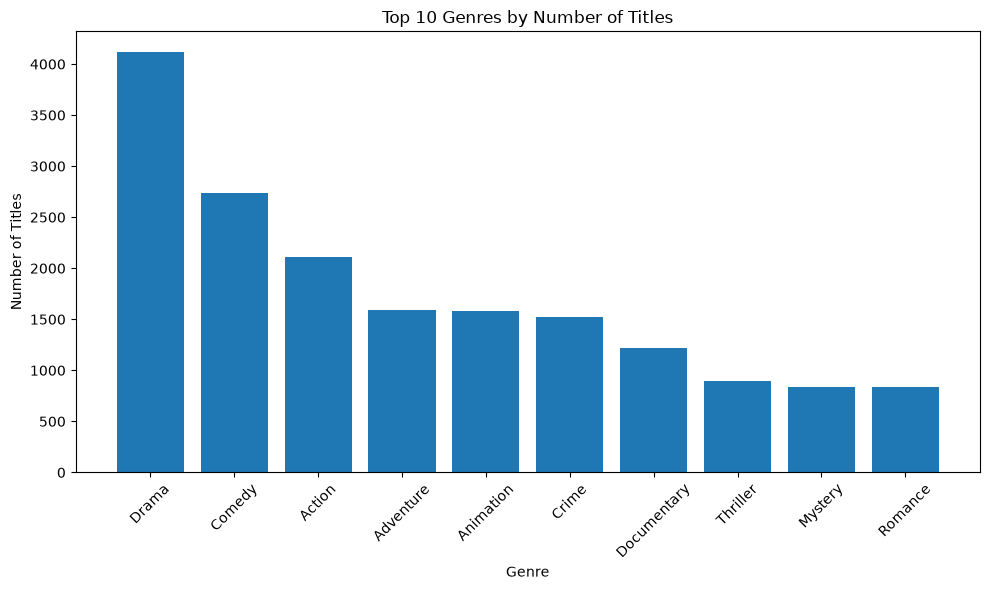

In [65]:
# Bar chart (Show the most represented genres.
# CHART 1
# GENRE DISTRIBUTION

top_10_genres = genre_count_df.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_genres["Genre"],
    top_10_genres["Movie_Count"]
)

plt.title("Top 10 Genres by Number of Titles")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

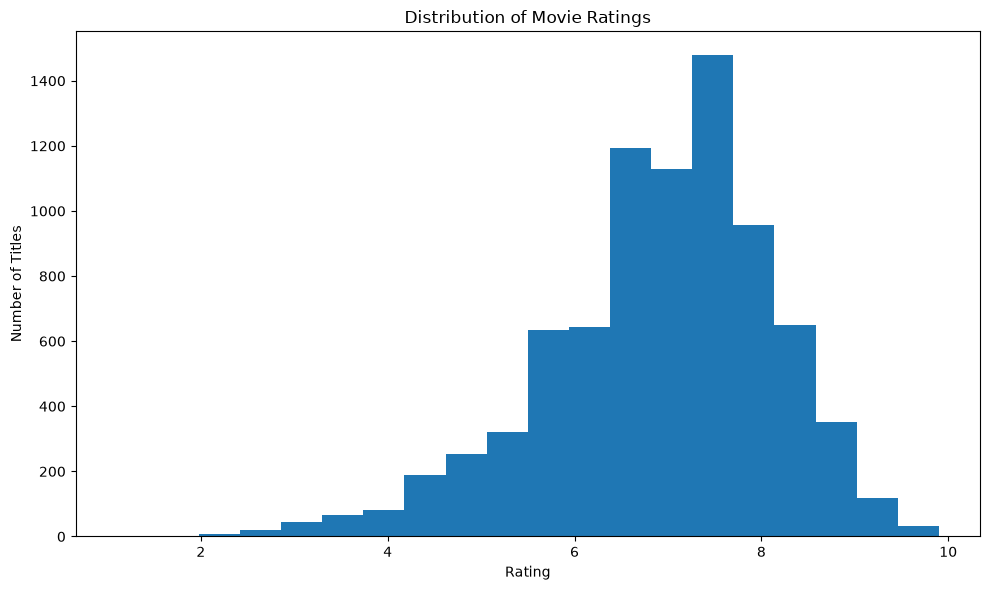

In [66]:
# Histogram
# CHART 2
# RATING DISTRIBUTION


plt.figure(figsize=(10, 6))

plt.hist(
    df["RATING"].dropna(),
    bins=20
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

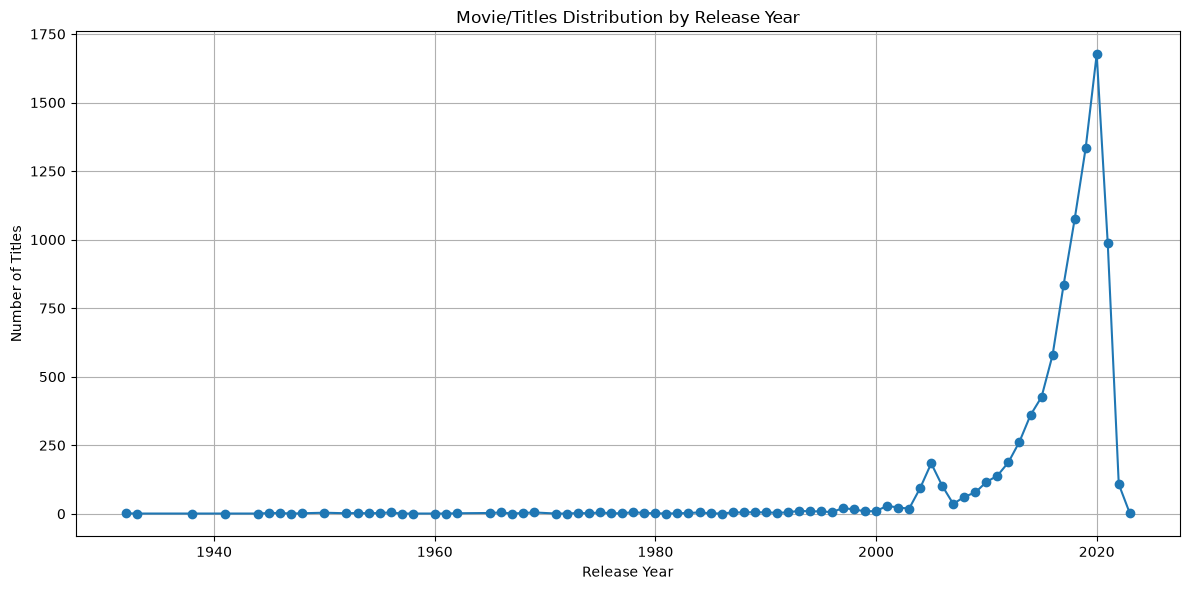

In [67]:
# Line chart
# CHART 3
# RELEASE YEAR TREND


plt.figure(figsize=(12, 6))

plt.plot(
    year_counts["Release_Year"],
    year_counts["Movie_Count"],
    marker="o"
)

plt.title("Movie/Titles Distribution by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.tight_layout()
plt.show()

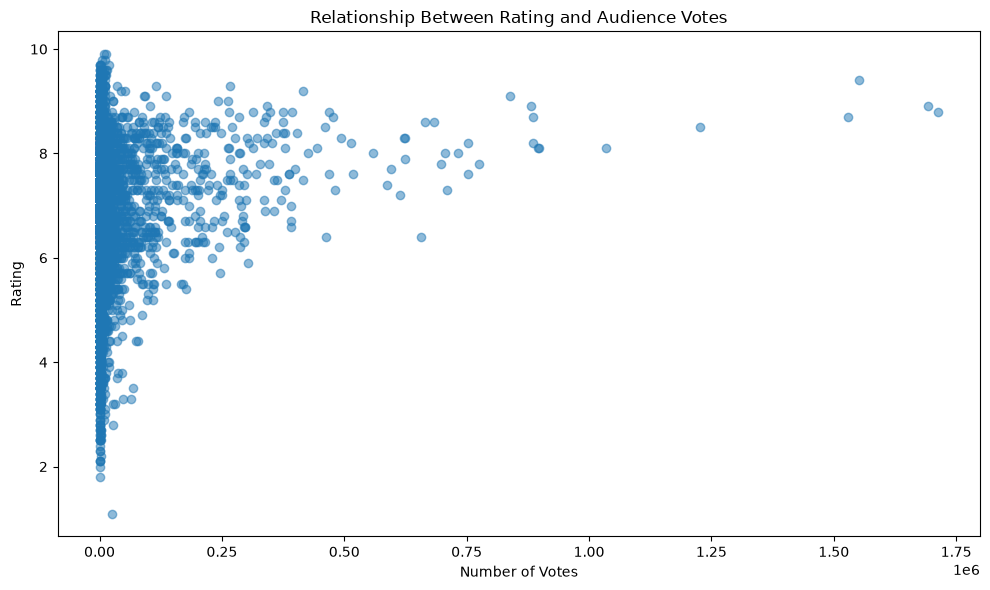

In [68]:
# Scatter plot
# CHART 4
# RATING VS VOTES


relationship_df = df.dropna(
    subset=["RATING", "VOTES"]
)

plt.figure(figsize=(10, 6))

plt.scatter(
    relationship_df["VOTES"],
    relationship_df["RATING"],
    alpha=0.5
)

plt.title("Relationship Between Rating and Audience Votes")
plt.xlabel("Number of Votes")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

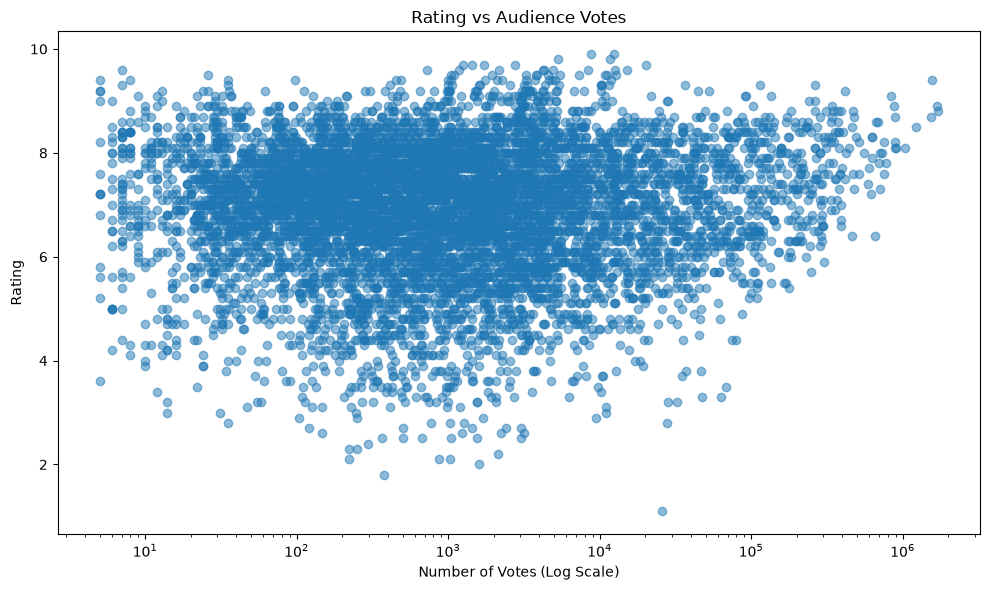

In [69]:
plt.figure(figsize=(10, 6))

plt.scatter(
    relationship_df["VOTES"],
    relationship_df["RATING"],
    alpha=0.5
)

plt.xscale("log")

plt.title("Rating vs Audience Votes")
plt.xlabel("Number of Votes (Log Scale)")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

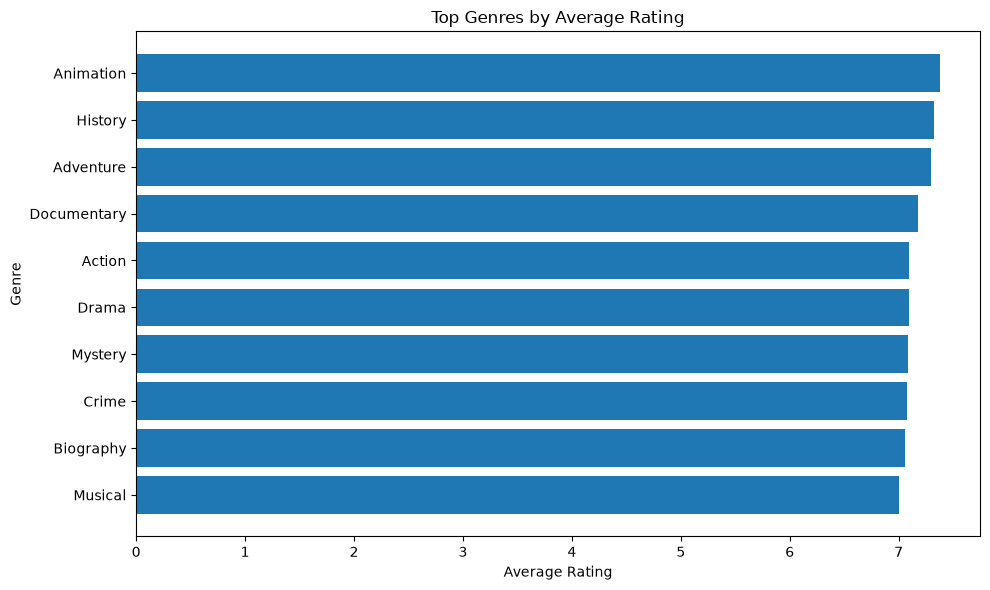

In [71]:
# Average rating by genre

# OPTIONAL CHART 5
# AVERAGE RATING BY GENRE

top_rating_genres = (
    genre_rating_filtered
    .head(10)
    .sort_values("Average_Rating")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_rating_genres.index,
    top_rating_genres["Average_Rating"]
)

plt.title("Top Genres by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

In [76]:
# ============================================================
# EXPORT CLEANED DATASET FOR MYSQL
# ============================================================

import csv

mysql_df = df.copy()

# Remove line breaks from text columns
for col in mysql_df.select_dtypes(include="object").columns:
    mysql_df[col] = (
        mysql_df[col]
        .astype("string")
        .str.replace(r"[\r\n]+", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

# IMPORTANT: This creates a REAL CSV file
cleaned_file = "cleaned_movies_mysql.csv"

mysql_df.to_csv(
    cleaned_file,
    index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_ALL,
    quotechar='"',
    lineterminator="\n"
)

print("CSV created successfully!")
print("File:", cleaned_file)
print("Rows:", len(mysql_df))
print("Columns:", len(mysql_df.columns))

C:\Users\abhijit\AppData\Local\Temp\ipykernel_3104\3025043171.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in mysql_df.select_dtypes(include="object").columns:


CSV created successfully!
File: cleaned_movies_mysql.csv
Rows: 9568
Columns: 10


In [77]:
import os

print(os.path.abspath("cleaned_movies_mysql.csv"))

C:\Users\abhijit\movies insight hackathon sprk\cleaned_movies_mysql.csv


In [78]:
import shutil
import os

source = r"C:\Users\abhijit\movies_insight_hackathon_sprk\cleaned_movies_mysql.csv"

destination = r"C:\ProgramData\MySQL\MySQL Server 8.0\Uploads\cleaned_movies_mysql.csv"

shutil.copy2(source, destination)

print("File copied successfully!")
print("Destination:", destination)
print("File exists:", os.path.exists(destination))
print("File size:", os.path.getsize(destination), "bytes")

FileNotFoundError: [WinError 3] The system cannot find the path specified